#  Hanoi puzzle and recursive solution

In [1]:
def move(source='A', target='C'):
    print(f"Move disk from {source} to {target}")

move()
move('peg 1', 'peg 3')
move(source='peg A', target='peg B')

Move disk from A to C
Move disk from peg 1 to peg 3
Move disk from peg A to peg B


In [2]:
def hanoi(n, source='A', target='C', auxiliary='B'):
    if n > 0:
        n1=hanoi(n-1, source=source, target=auxiliary, auxiliary=target) # move all but one to the auxiliary peg
        move(source,target) # move the biggest disk to the target peg
        n2=hanoi(n-1, source=auxiliary, target=target, auxiliary=source) # move all but one from the auxiliary peg to the target peg
        return n1+n2+1
    else:
        return 0

print(hanoi(6))

Move disk from A to B
Move disk from A to C
Move disk from B to C
Move disk from A to B
Move disk from C to A
Move disk from C to B
Move disk from A to B
Move disk from A to C
Move disk from B to C
Move disk from B to A
Move disk from C to A
Move disk from B to C
Move disk from A to B
Move disk from A to C
Move disk from B to C
Move disk from A to B
Move disk from C to A
Move disk from C to B
Move disk from A to B
Move disk from C to A
Move disk from B to C
Move disk from B to A
Move disk from C to A
Move disk from C to B
Move disk from A to B
Move disk from A to C
Move disk from B to C
Move disk from A to B
Move disk from C to A
Move disk from C to B
Move disk from A to B
Move disk from A to C
Move disk from B to C
Move disk from B to A
Move disk from C to A
Move disk from B to C
Move disk from A to B
Move disk from A to C
Move disk from B to C
Move disk from B to A
Move disk from C to A
Move disk from C to B
Move disk from A to B
Move disk from C to A
Move disk from B to C
Move disk 

## Visualizing the solution

Represent each peg by a list. The largest disk is at the beginning of a list and the top disk is at the end. The animation starts with all disks on the source peg, then applies the recursive sequence one move at a time.

In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from IPython.display import HTML


def initial_position(n, source='A', target='C', auxiliary='B'):
    """Return the initial contents of the three pegs."""
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError('n must be a positive integer')
    if len({source, target, auxiliary}) != 3:
        raise ValueError('the three peg names must be different')

    return {
        source: list(range(n, 0, -1)),
        auxiliary: [],
        target: [],
    }


def hanoi_moves(n, source='A', target='C', auxiliary='B'):
    """Generate the moves in the same order as hanoi()."""
    if n > 0:
        yield from hanoi_moves(n - 1, source, auxiliary, target)
        yield source, target
        yield from hanoi_moves(n - 1, auxiliary, target, source)


def hanoi_states(n, source='A', target='C', auxiliary='B'):
    """Generate the initial position and every position after a move."""
    pegs = initial_position(n, source, target, auxiliary)
    yield 0, None, {name: disks.copy() for name, disks in pegs.items()}

    for step, (old_peg, new_peg) in enumerate(
        hanoi_moves(n, source, target, auxiliary), start=1
    ):
        disk = pegs[old_peg].pop()
        if pegs[new_peg] and pegs[new_peg][-1] < disk:
            raise RuntimeError('illegal move: a larger disk cannot cover a smaller disk')
        pegs[new_peg].append(disk)
        position = {name: disks.copy() for name, disks in pegs.items()}
        yield step, (disk, old_peg, new_peg), position

### The pegs as text

No plotting needed to see what is going on: each peg is a column, each disk a bar of
width proportional to its size, and the top of a peg is the top of its list.

In [4]:
def show_position(position, label=None):
    """Return a text picture of one position, largest disk at the bottom."""
    n = sum(len(disks) for disks in position.values())
    width = 2 * n + 1
    lines = [] if label is None else [label]

    for level in range(n - 1, -1, -1):  # draw from the top level down
        row = []
        for disks in position.values():
            if level < len(disks):
                row.append(('█' * (2 * disks[level] - 1)).center(width))
            else:
                row.append('│'.center(width))
        lines.append('  '.join(row))

    lines.append('  '.join('─' * width for _ in position))
    lines.append('  '.join(str(name).center(width) for name in position))
    return '\n'.join(lines)


def print_moves(n, source='A', target='C', auxiliary='B'):
    """Print the initial position and every position the solution passes through."""
    for step, move_data, position in hanoi_states(n, source, target, auxiliary):
        if move_data is None:
            label = f'Initial position, {n} disks on peg {source}'
        else:
            disk, old_peg, new_peg = move_data
            label = f'Move {step}: disk {disk} from {old_peg} to {new_peg}'
        print(show_position(position, label=label), end='\n\n')


print(show_position(initial_position(4), label='Where we start'))

Where we start
    █          │          │    
   ███         │          │    
  █████        │          │    
 ███████       │          │    
─────────  ─────────  ─────────
    A          B          C    


In [5]:
print_moves(5)

Initial position, 5 disks on peg A
     █            │            │     
    ███           │            │     
   █████          │            │     
  ███████         │            │     
 █████████        │            │     
───────────  ───────────  ───────────
     A            B            C     

Move 1: disk 1 from A to C
     │            │            │     
    ███           │            │     
   █████          │            │     
  ███████         │            │     
 █████████        │            █     
───────────  ───────────  ───────────
     A            B            C     

Move 2: disk 2 from A to B
     │            │            │     
     │            │            │     
   █████          │            │     
  ███████         │            │     
 █████████       ███           █     
───────────  ───────────  ───────────
     A            B            C     

Move 3: disk 1 from C to B
     │            │            │     
     │            │            │     
   ████

In [ ]:
def draw_hanoi(position, title=None, ax=None):
    """Draw one position of the puzzle and return its axes."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    else:
        ax.clear()

    peg_names = list(position)
    n = sum(len(disks) for disks in position.values())
    disk_height = 0.65
    base_y = 0.25

    ax.plot([-0.55, 2.55], [base_y, base_y], color='0.25', linewidth=3)
    for x, (name, disks) in enumerate(position.items()):
        ax.plot(
            [x, x], [base_y, base_y + disk_height * (n + 0.6)],
            color='0.35', linewidth=3, zorder=0,
        )
        for level, disk in enumerate(disks):
            width = 0.35 + 0.95 * disk / n
            rectangle = Rectangle(
                (x - width / 2, base_y + level * disk_height),
                width, disk_height * 0.82,
                facecolor=plt.cm.viridis(0.15 + 0.7 * disk / n),
                edgecolor='0.15',
                linewidth=1.2,
                zorder=1,
            )
            ax.add_patch(rectangle)
            ax.text(
                x, base_y + (level + 0.41) * disk_height, str(disk),
                ha='center', va='center', color='white', fontweight='bold',
                zorder=2,
            )

    ax.set_xticks(range(3), peg_names)
    ax.set_xlim(-0.7, 2.7)
    ax.set_ylim(0, base_y + disk_height * (n + 1))
    ax.set_yticks([])
    ax.tick_params(axis='x', length=0, labelsize=12)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title is not None:
        ax.set_title(title)
    return ax


def animate_hanoi(n, source='A', target='C', auxiliary='B', interval=700):
    """Return a notebook animation, beginning with the initial position."""
    states = list(hanoi_states(n, source, target, auxiliary))
    figure, ax = plt.subplots(figsize=(8, 4))

    def update(frame):
        step, move_data, position = states[frame]
        if move_data is None:
            title = 'Initial position'
        else:
            disk, old_peg, new_peg = move_data
            title = f'Move {step} of {len(states) - 1}: disk {disk}, {old_peg} → {new_peg}'
        draw_hanoi(position, title=title, ax=ax)

    animation = FuncAnimation(
        figure, update, frames=len(states), interval=interval, repeat=False
    )
    plt.close(figure)
    return HTML(animation.to_jshtml())

In [7]:
# Frame 0 is the initial position; use the controls to step through the moves.
animate_hanoi(8)

### All positions at once

The animation needs a live kernel or a browser. The same states also fit into a grid of
panels, which is what to use in printed notes, or to compare the shape of the solution
for different `n`.

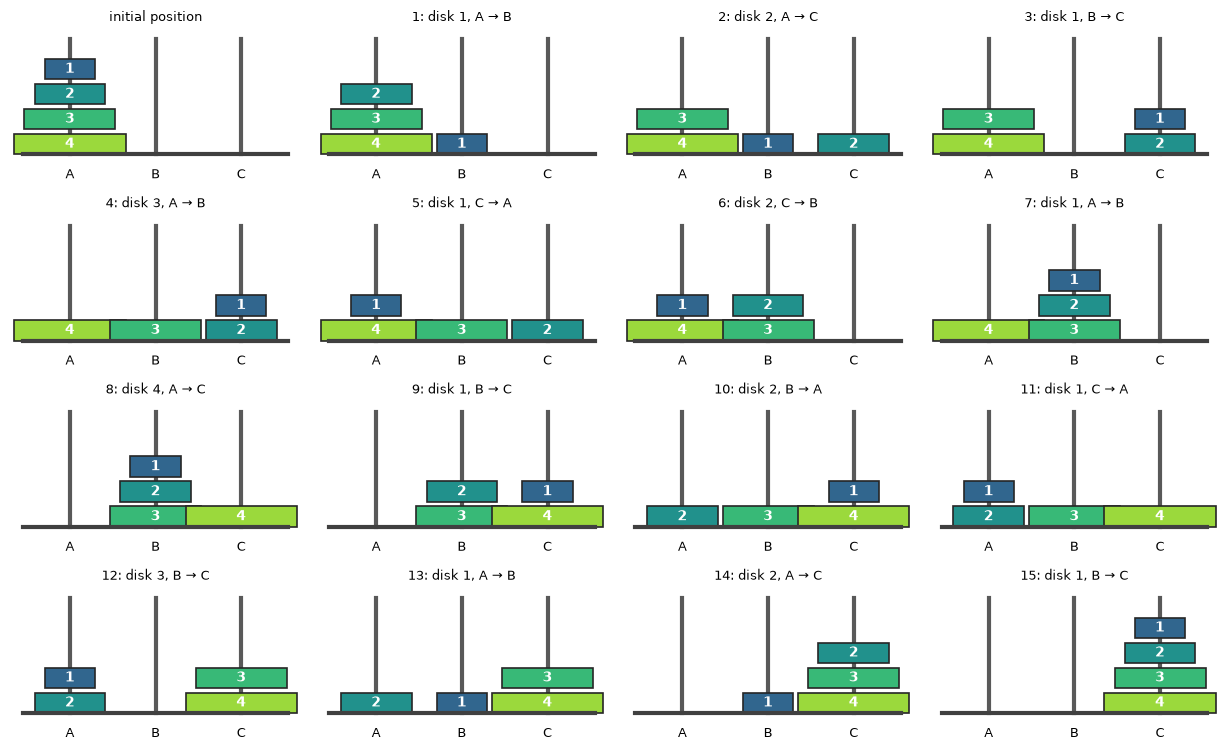

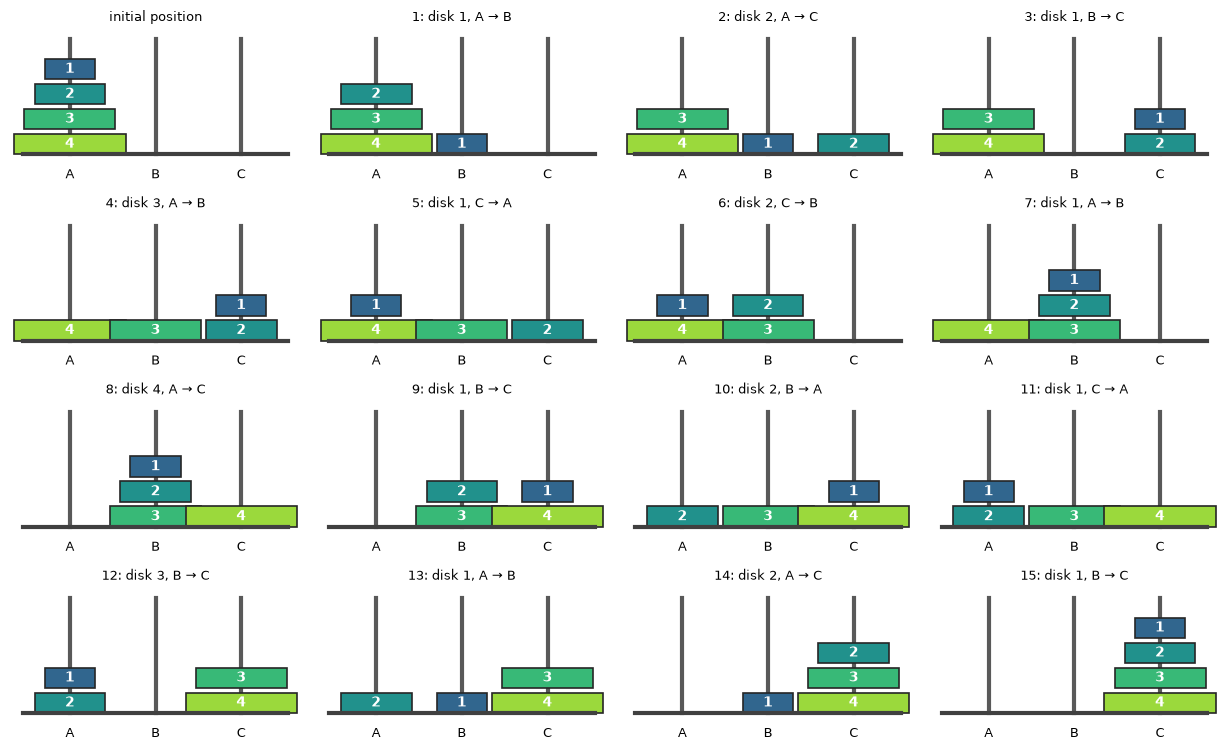

In [9]:
def plot_hanoi_sequence(n, source='A', target='C', auxiliary='B', ncols=4):
    """Plot the initial position and every position after a move in one grid."""
    states = list(hanoi_states(n, source, target, auxiliary))
    nrows = -(-len(states) // ncols)  # ceiling division
    figure, axes = plt.subplots(
        nrows, ncols, figsize=(3.1 * ncols, 1.9 * nrows), squeeze=False
    )

    for ax, (step, move_data, position) in zip(axes.flat, states):
        if move_data is None:
            title = 'initial position'
        else:
            disk, old_peg, new_peg = move_data
            title = f'{step}: disk {disk}, {old_peg} → {new_peg}'
        draw_hanoi(position, title=title, ax=ax)
        ax.set_title(title, fontsize=9)
        ax.tick_params(axis='x', labelsize=9)

    for ax in axes.flat[len(states):]:  # blank out the unused panels
        ax.axis('off')

    figure.tight_layout()
    return figure


plot_hanoi_sequence(4)